# Image Classification using Pretrained Vision Transformer vs CNN

## Deep Learning Laboratory

### Assignment
**Perform Image classification using Pretrained Vision Transformer model and compare its performance with CNN Model.**

### Objective
Compare a CNN trained from scratch with an ImageNet-pretrained **Vision Transformer (ViT-B/16)** for multiclass image classification using CIFAR-10.

### Learning Outcomes
- Understand CNN-based image classification.
- Understand Vision Transformer patch embeddings and self-attention.
- Apply transfer learning and fine-tuning.
- Compare models using objective classification metrics.
- Analyze confusion matrices and model complexity.

## 1. Background

CNNs learn spatial features using convolution operations. Vision Transformers divide an image into patches and use Transformer self-attention to learn relationships between patches.

In this experiment, the CNN starts with random weights, while ViT-B/16 starts from ImageNet-pretrained weights. Both are adapted to the same CIFAR-10 task.

## 2. Dataset — CIFAR-10

CIFAR-10 contains 60,000 RGB images across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. Images are 32×32 pixels.

For practical training on a Local GPU, this notebook defaults to a configurable subset. Set `TRAIN_SAMPLES = None` and `TEST_SAMPLES = None` to use the complete splits.

In [2]:
# 3. Setup
import sys, random
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
from torchvision.models import ViT_B_16_Weights
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from tqdm.auto import tqdm

SEED=42
TRAIN_SAMPLES=10000
TEST_SAMPLES=2000
EPOCHS_CNN=5
EPOCHS_VIT=3
BATCH_SIZE_CNN=64
BATCH_SIZE_VIT=8
NUM_WORKERS=2
NUM_CLASSES=10
CLASS_NAMES=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
DATA_DIR=ROOT/'data'; MODEL_DIR=ROOT/'models'; OUTPUT_DIR=ROOT/'outputs'
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('PyTorch:',torch.__version__); print('Device:',device)
if torch.cuda.is_available(): print('GPU:',torch.cuda.get_device_name(0))

PyTorch: 2.14.0+cu130
Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 3. Dataset Exploration

We first inspect the dataset size, class names, class balance and sample images.

In [3]:
raw_train=datasets.CIFAR10(DATA_DIR,train=True,download=True)
raw_test=datasets.CIFAR10(DATA_DIR,train=False,download=True)
print('Training samples:',len(raw_train))
print('Test samples:',len(raw_test))
print('Classes:',raw_train.classes)

100%|██████████| 170M/170M [01:49<00:00, 1.55MB/s] 


Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


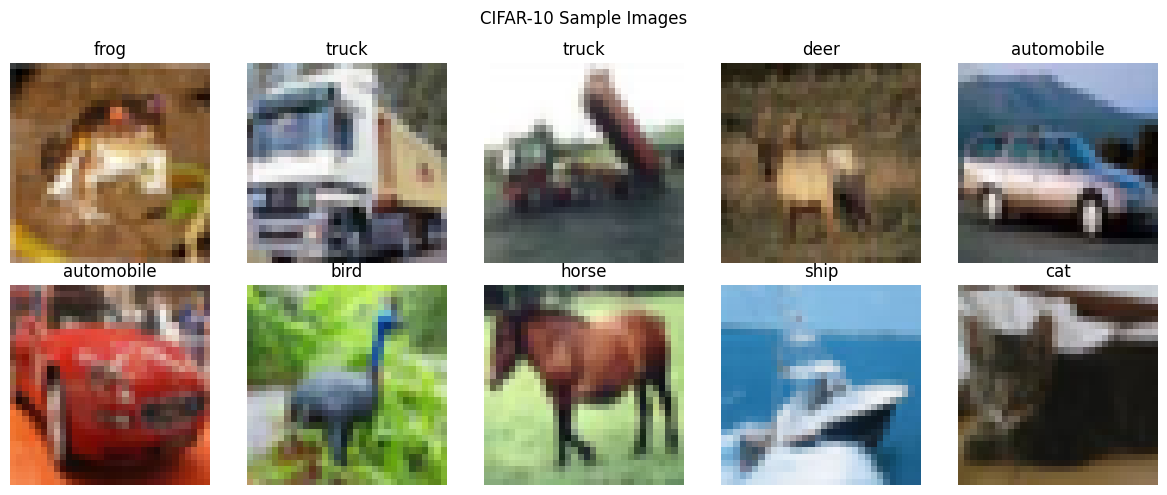

In [4]:
fig,axes=plt.subplots(2,5,figsize=(12,5))
for ax,i in zip(axes.flat,range(10)):
    image,label=raw_train[i]; ax.imshow(image); ax.set_title(raw_train.classes[label]); ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images'); plt.tight_layout(); plt.show()

,count
airplane,5000
automobile,5000
bird,5000
cat,5000
deer,5000
dog,5000
frog,5000
horse,5000
ship,5000
truck,5000


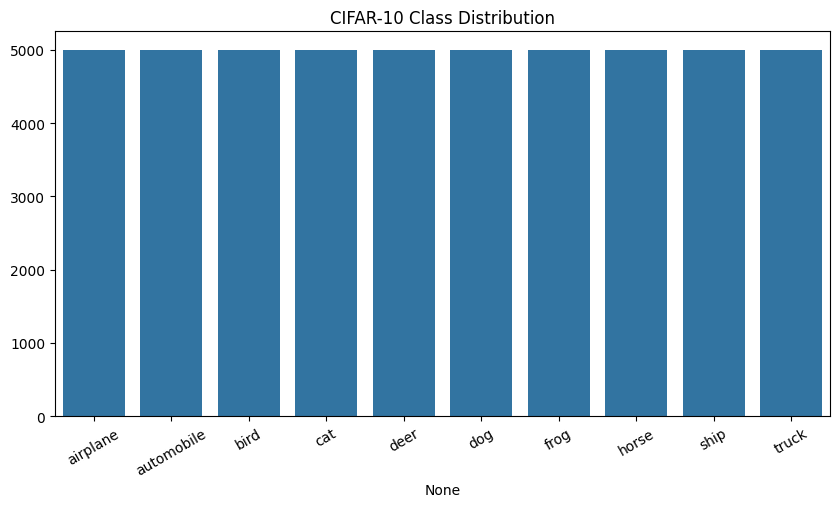

In [5]:
counts=pd.Series(raw_train.targets).value_counts().sort_index(); counts.index=CLASS_NAMES
display(counts.to_frame('count'))
plt.figure(figsize=(10,5)); sns.barplot(x=counts.index,y=counts.values); plt.title('CIFAR-10 Class Distribution'); plt.xticks(rotation=30); plt.show()

## 4. Preprocessing

The CNN keeps the native 32×32 resolution. ViT receives 224×224 inputs because its pretrained ImageNet representation expects that input scale. Training augmentation is applied separately so that both architectures receive appropriate inputs.

In [6]:
cmean=(.4914,.4822,.4465); cstd=(.2470,.2435,.2616)
im=(.485,.456,.406); ist=(.229,.224,.225)
train_cnn_tf=transforms.Compose([transforms.RandomCrop(32,padding=4),transforms.RandomHorizontalFlip(),transforms.ToTensor(),transforms.Normalize(cmean,cstd)])
test_cnn_tf=transforms.Compose([transforms.ToTensor(),transforms.Normalize(cmean,cstd)])
train_vit_tf=transforms.Compose([transforms.RandomResizedCrop(224,scale=(.8,1.0)),transforms.RandomHorizontalFlip(),transforms.ToTensor(),transforms.Normalize(im,ist)])
test_vit_tf=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),transforms.Normalize(im,ist)])
cnn_full=datasets.CIFAR10(DATA_DIR,train=True,download=True,transform=train_cnn_tf)
cnn_test=datasets.CIFAR10(DATA_DIR,train=False,download=True,transform=test_cnn_tf)
vit_full=datasets.CIFAR10(DATA_DIR,train=True,download=True,transform=train_vit_tf)
vit_test=datasets.CIFAR10(DATA_DIR,train=False,download=True,transform=test_vit_tf)
if TRAIN_SAMPLES is not None:
    idx=list(range(TRAIN_SAMPLES)); cnn_full=Subset(cnn_full,idx); vit_full=Subset(vit_full,idx)
if TEST_SAMPLES is not None:
    idx=list(range(TEST_SAMPLES)); cnn_test=Subset(cnn_test,idx); vit_test=Subset(vit_test,idx)
# 90/10 train-validation split; test set remains untouched.
g=torch.Generator().manual_seed(SEED); nval=max(1,int(.1*len(cnn_full))); ntrain=len(cnn_full)-nval
cnn_train,cnn_val=random_split(cnn_full,[ntrain,nval],generator=g)
g=torch.Generator().manual_seed(SEED); vit_train,vit_val=random_split(vit_full,[ntrain,nval],generator=g)
cnn_train_loader=DataLoader(cnn_train,batch_size=BATCH_SIZE_CNN,shuffle=True,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
cnn_val_loader=DataLoader(cnn_val,batch_size=BATCH_SIZE_CNN,shuffle=False,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
cnn_test_loader=DataLoader(cnn_test,batch_size=BATCH_SIZE_CNN,shuffle=False,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
vit_train_loader=DataLoader(vit_train,batch_size=BATCH_SIZE_VIT,shuffle=True,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
vit_val_loader=DataLoader(vit_val,batch_size=BATCH_SIZE_VIT,shuffle=False,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
vit_test_loader=DataLoader(vit_test,batch_size=BATCH_SIZE_VIT,shuffle=False,num_workers=NUM_WORKERS,pin_memory=torch.cuda.is_available())
print('CNN train/val/test:',len(cnn_train),len(cnn_val),len(cnn_test)); print('ViT train/val/test:',len(vit_train),len(vit_val),len(vit_test))

CNN train/val/test: 9000 1000 2000
ViT train/val/test: 9000 1000 2000


## 5. CNN Baseline

The CNN uses convolution, batch normalization, ReLU, max pooling, adaptive average pooling and dropout. It is trained from scratch.

In [7]:
class CNNClassifier(nn.Module):
    def __init__(self,num_classes=10):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(),
            nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(),nn.AdaptiveAvgPool2d((1,1)))
        self.classifier=nn.Sequential(nn.Flatten(),nn.Dropout(.3),nn.Linear(256,num_classes))
    def forward(self,x): return self.classifier(self.features(x))
cnn=CNNClassifier().to(device)
print(cnn); print('CNN parameters:',f'{sum(p.numel() for p in cnn.parameters()):,}')

CNNClassifier(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(12

In [8]:
def get_metrics(y,p):
    pr,re,f1,_=precision_recall_fscore_support(y,p,average='weighted',zero_division=0)
    return {'accuracy':accuracy_score(y,p),'precision':pr,'recall':re,'f1':f1}

@torch.no_grad()
def evaluate(model,loader,criterion):
    model.eval(); loss_sum=0.; y=[]; p=[]
    for x,t in loader:
        x=x.to(device); t=t.to(device); out=model(x); loss_sum+=criterion(out,t).item()*x.size(0); y.extend(t.cpu().numpy()); p.extend(out.argmax(1).cpu().numpy())
    m=get_metrics(y,p); m.update({'loss':loss_sum/len(loader.dataset),'y_true':y,'y_pred':p}); return m

def train(model,train_loader,val_loader,epochs,lr,wd,name):
    criterion=nn.CrossEntropyLoss(); opt=optim.AdamW(model.parameters(),lr=lr,weight_decay=wd); sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs); scaler=torch.amp.GradScaler('cuda') if device.type=='cuda' else None
    hist={'train_loss':[],'train_accuracy':[],'val_loss':[],'val_accuracy':[]}; best=-1; Path(MODEL_DIR/name).mkdir(parents=True,exist_ok=True)
    for e in range(epochs):
        model.train(); ls=0.; y=[]; p=[]
        for x,t in tqdm(train_loader,desc=f'{name} Epoch {e+1}/{epochs}'):
            x=x.to(device); t=t.to(device); opt.zero_grad(set_to_none=True); amp=scaler is not None
            with torch.autocast(device_type='cuda',dtype=torch.float16,enabled=amp): out=model(x); loss=criterion(out,t)
            if scaler: scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            else: loss.backward(); opt.step()
            ls+=loss.item()*x.size(0); y.extend(t.detach().cpu().numpy()); p.extend(out.argmax(1).detach().cpu().numpy())
        sched.step(); tr=get_metrics(y,p); val=evaluate(model,val_loader,criterion)
        hist['train_loss'].append(ls/len(train_loader.dataset)); hist['train_accuracy'].append(tr['accuracy']); hist['val_loss'].append(val['loss']); hist['val_accuracy'].append(val['accuracy'])
        print(f'{name} | epoch {e+1}: train_acc={tr["accuracy"]:.4f}, val_acc={val["accuracy"]:.4f}')
        if val['accuracy']>best: best=val['accuracy']; torch.save(model.state_dict(),MODEL_DIR/name/f'{name.lower()}_cifar10.pth')
    return hist

In [9]:
cnn_history=train(cnn,cnn_train_loader,cnn_val_loader,EPOCHS_CNN,1e-3,1e-4,'cnn')
cnn.load_state_dict(torch.load(MODEL_DIR/'cnn'/'cnn_cifar10.pth',map_location=device,weights_only=True))
cnn_test_metrics=evaluate(cnn,cnn_test_loader,nn.CrossEntropyLoss())
print(cnn_test_metrics)

cnn Epoch 1/5: 100%|██████████| 141/141 [00:05<00:00, 26.40it/s]


cnn | epoch 1: train_acc=0.3517, val_acc=0.3880


cnn Epoch 2/5: 100%|██████████| 141/141 [00:03<00:00, 45.20it/s]


cnn | epoch 2: train_acc=0.4959, val_acc=0.4930


cnn Epoch 3/5: 100%|██████████| 141/141 [00:01<00:00, 70.73it/s]


cnn | epoch 3: train_acc=0.5699, val_acc=0.5370


cnn Epoch 4/5: 100%|██████████| 141/141 [00:01<00:00, 71.67it/s]


cnn | epoch 4: train_acc=0.6343, val_acc=0.6010


cnn Epoch 5/5: 100%|██████████| 141/141 [00:01<00:00, 71.87it/s]


cnn | epoch 5: train_acc=0.6686, val_acc=0.6450
{'accuracy': 0.656, 'precision': 0.6516696970310903, 'recall': 0.656, 'f1': 0.6500143260821857, 'loss': 0.9556009311676026, 'y_true': [np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6), np.int64(6), np.int64(1), np.int64(6), np.int64(3), np.int64(1), np.int64(0), np.int64(9), np.int64(5), np.int64(7), np.int64(9), np.int64(8), np.int64(5), np.int64(7), np.int64(8), np.int64(6), np.int64(7), np.int64(0), np.int64(4), np.int64(9), np.int64(5), np.int64(2), np.int64(4), np.int64(0), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(5), np.int64(9), np.int64(2), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(4), np.int64(6), np.int64(5), np.int64(6), np.int64(0), np.int64(9), np.int64(3), np.int64(9), np.int64(7), np.int64(6), np.int64(9), np.int64(8), np.int64(0), np.int64(3), np.int64(8), np.int64(8), np.int64(7), np.int64(7), np.int64(4), np.int64(6), np.int64(7), np.int64(3), np.int64(6)

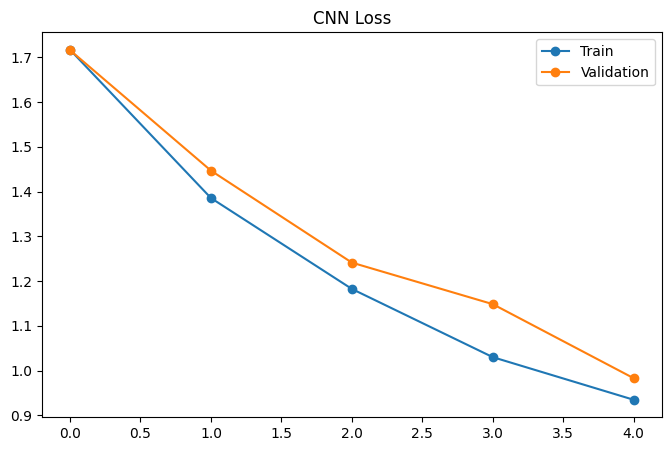

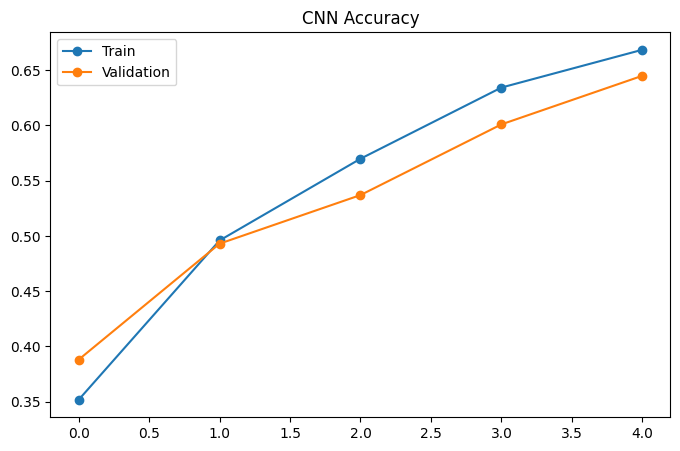

In [10]:
plt.figure(figsize=(8,5)); plt.plot(cnn_history['train_loss'],marker='o',label='Train'); plt.plot(cnn_history['val_loss'],marker='o',label='Validation'); plt.title('CNN Loss'); plt.legend(); plt.show()
plt.figure(figsize=(8,5)); plt.plot(cnn_history['train_accuracy'],marker='o',label='Train'); plt.plot(cnn_history['val_accuracy'],marker='o',label='Validation'); plt.title('CNN Accuracy'); plt.legend(); plt.show()

## 6. Pretrained Vision Transformer

We load `ViT-B/16` with ImageNet-pretrained weights. The original 1000-class ImageNet head is replaced by a 10-class CIFAR-10 head. The complete model is fine-tuned.

In [11]:
vit=models.vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
vit.heads.head=nn.Linear(vit.heads.head.in_features,NUM_CLASSES)
vit=vit.to(device)
print('ViT parameters:',f'{sum(p.numel() for p in vit.parameters()):,}')

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /home/rohan/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:24<00:00, 14.1MB/s] 


ViT parameters: 85,806,346


In [12]:
vit_history=train(vit,vit_train_loader,vit_val_loader,EPOCHS_VIT,2e-5,.01,'vit_b16')
vit.load_state_dict(torch.load(MODEL_DIR/'vit_b16'/'vit_b16_cifar10.pth',map_location=device,weights_only=True))
vit_test_metrics=evaluate(vit,vit_test_loader,nn.CrossEntropyLoss())
print(vit_test_metrics)

vit_b16 Epoch 1/3: 100%|██████████| 1125/1125 [02:31<00:00,  7.41it/s]


vit_b16 | epoch 1: train_acc=0.9051, val_acc=0.9420


vit_b16 Epoch 2/3: 100%|██████████| 1125/1125 [02:55<00:00,  6.42it/s]


vit_b16 | epoch 2: train_acc=0.9742, val_acc=0.9580


vit_b16 Epoch 3/3: 100%|██████████| 1125/1125 [02:14<00:00,  8.37it/s]


vit_b16 | epoch 3: train_acc=0.9918, val_acc=0.9660
{'accuracy': 0.9695, 'precision': 0.9695133517738103, 'recall': 0.9695, 'f1': 0.9694663659621936, 'loss': 0.08393215160537511, 'y_true': [np.int64(3), np.int64(8), np.int64(8), np.int64(0), np.int64(6), np.int64(6), np.int64(1), np.int64(6), np.int64(3), np.int64(1), np.int64(0), np.int64(9), np.int64(5), np.int64(7), np.int64(9), np.int64(8), np.int64(5), np.int64(7), np.int64(8), np.int64(6), np.int64(7), np.int64(0), np.int64(4), np.int64(9), np.int64(5), np.int64(2), np.int64(4), np.int64(0), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(5), np.int64(9), np.int64(2), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(4), np.int64(6), np.int64(5), np.int64(6), np.int64(0), np.int64(9), np.int64(3), np.int64(9), np.int64(7), np.int64(6), np.int64(9), np.int64(8), np.int64(0), np.int64(3), np.int64(8), np.int64(8), np.int64(7), np.int64(7), np.int64(4), np.int64(6), np.int64(7), np.int64(3), np.i

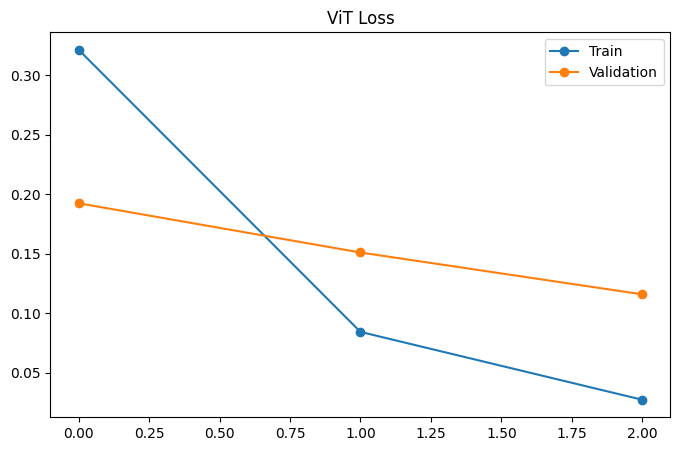

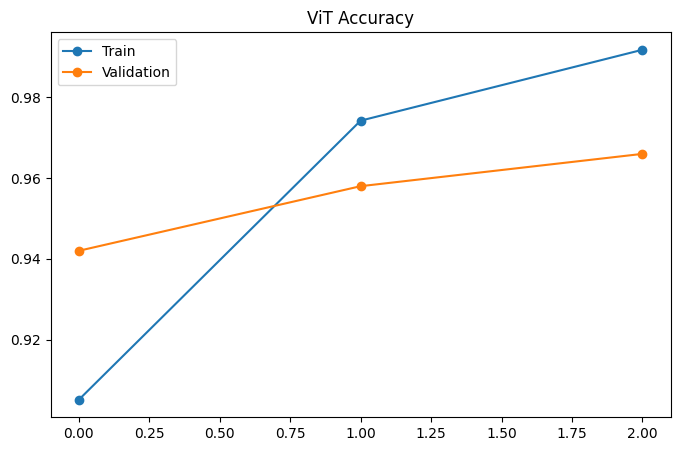

In [13]:
plt.figure(figsize=(8,5)); plt.plot(vit_history['train_loss'],marker='o',label='Train'); plt.plot(vit_history['val_loss'],marker='o',label='Validation'); plt.title('ViT Loss'); plt.legend(); plt.show()
plt.figure(figsize=(8,5)); plt.plot(vit_history['train_accuracy'],marker='o',label='Train'); plt.plot(vit_history['val_accuracy'],marker='o',label='Validation'); plt.title('ViT Accuracy'); plt.legend(); plt.show()

## 7. Final Test Evaluation

The test set has not been used for checkpoint selection. The best checkpoint according to validation accuracy is evaluated once on the held-out test set.

In [14]:
print('CNN Classification Report')
print(classification_report(cnn_test_metrics['y_true'],cnn_test_metrics['y_pred'],target_names=CLASS_NAMES,digits=4))
print('ViT Classification Report')
print(classification_report(vit_test_metrics['y_true'],vit_test_metrics['y_pred'],target_names=CLASS_NAMES,digits=4))

CNN Classification Report
              precision    recall  f1-score   support

    airplane     0.6250    0.6633    0.6436       196
  automobile     0.8366    0.8535    0.8450       198
        bird     0.4709    0.4974    0.4838       195
         cat     0.4737    0.3618    0.4103       199
        deer     0.5806    0.5455    0.5625       198
         dog     0.5724    0.4486    0.5030       185
        frog     0.6721    0.7685    0.7171       216
       horse     0.7302    0.7150    0.7225       193
        ship     0.6842    0.8986    0.7769       217
       truck     0.8556    0.7586    0.8042       203

    accuracy                         0.6560      2000
   macro avg     0.6501    0.6511    0.6469      2000
weighted avg     0.6517    0.6560    0.6500      2000

ViT Classification Report
              precision    recall  f1-score   support

    airplane     0.9844    0.9643    0.9742       196
  automobile     0.9700    0.9798    0.9749       198
        bird     0.9747   

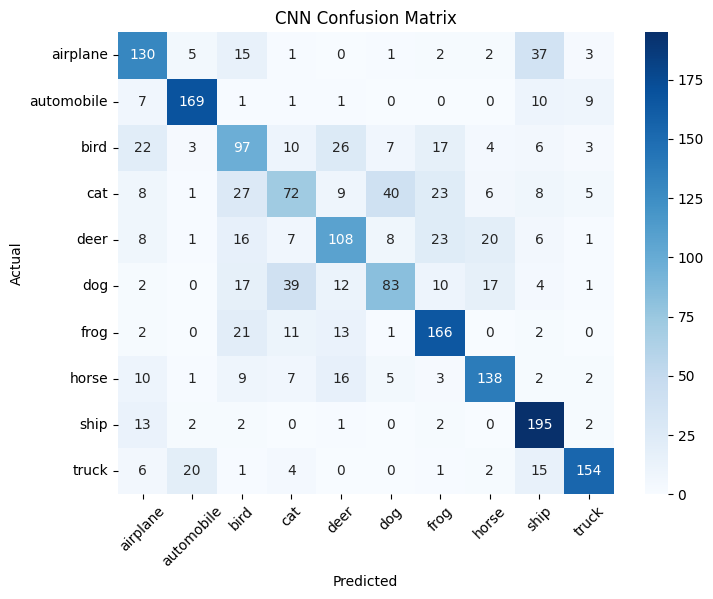

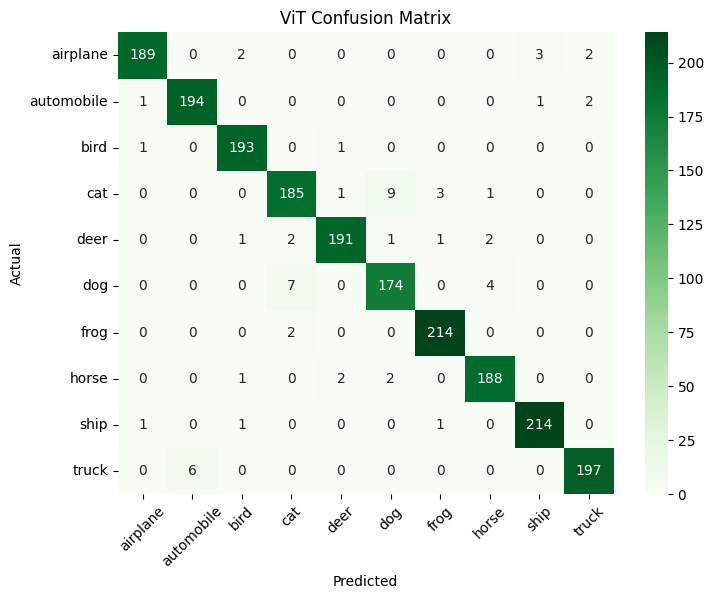

In [15]:
cnn_cm=confusion_matrix(cnn_test_metrics['y_true'],cnn_test_metrics['y_pred']); vit_cm=confusion_matrix(vit_test_metrics['y_true'],vit_test_metrics['y_pred'])
plt.figure(figsize=(8,6)); sns.heatmap(cnn_cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES); plt.title('CNN Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.xticks(rotation=45); plt.show()
plt.figure(figsize=(8,6)); sns.heatmap(vit_cm,annot=True,fmt='d',cmap='Greens',xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES); plt.title('ViT Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.xticks(rotation=45); plt.show()

,Model,Accuracy,Precision,Recall,F1-score,Parameters
0,CNN,0.6560,0.651670,0.6560,0.650014,1149770
1,Pretrained ViT-B/16,0.9695,0.969513,0.9695,0.969466,85806346


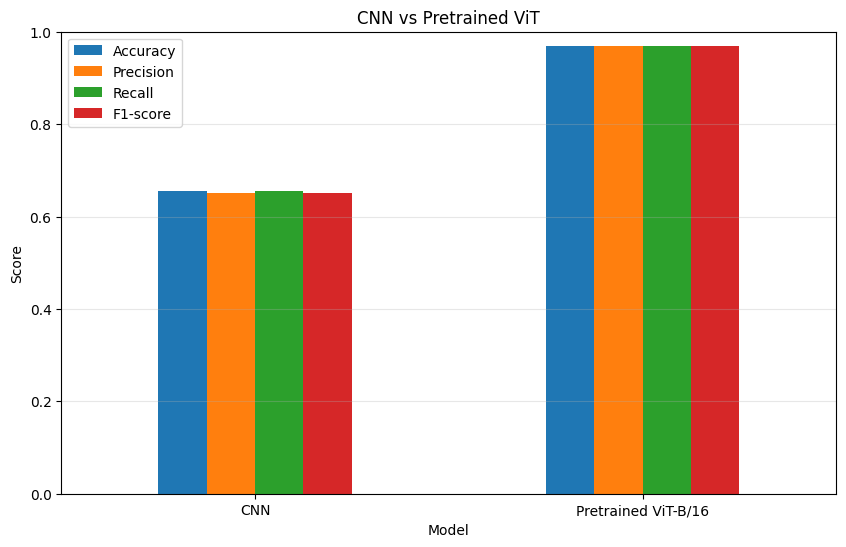

In [16]:
comparison=pd.DataFrame({
 'Model':['CNN','Pretrained ViT-B/16'],
 'Accuracy':[cnn_test_metrics['accuracy'],vit_test_metrics['accuracy']],
 'Precision':[cnn_test_metrics['precision'],vit_test_metrics['precision']],
 'Recall':[cnn_test_metrics['recall'],vit_test_metrics['recall']],
 'F1-score':[cnn_test_metrics['f1'],vit_test_metrics['f1']],
 'Parameters':[sum(p.numel() for p in cnn.parameters()),sum(p.numel() for p in vit.parameters())]})
display(comparison)
comparison.set_index('Model')[['Accuracy','Precision','Recall','F1-score']].plot(kind='bar',figsize=(10,6)); plt.ylim(0,1); plt.title('CNN vs Pretrained ViT'); plt.ylabel('Score'); plt.xticks(rotation=0); plt.grid(axis='y',alpha=.3); plt.show()

## 8. Results and Discussion

Fill the following table using the measured results above.

| Model | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| CNN | 65.60% | 65.16% | 65.60% | 65.00% |
| Pretrained ViT-B/16 | 96.95% | 96.95% | 96.95% | 96.94% |

Discuss class-wise errors using the confusion matrices, and relate the results to model architecture, pretraining, parameter count, input resolution and computational cost. Avoid assuming a universal winner; the conclusion should reflect the measured experiment.

## 9. Conclusion

This experiment implemented image classification using a CNN trained from scratch and an ImageNet-pretrained Vision Transformer. The CNN learns local spatial patterns through convolution, while ViT represents images as patches and uses self-attention to model relationships between them.

Both models were evaluated on the same held-out CIFAR-10 test set using accuracy, precision, recall, F1-score and confusion matrices. The experiment demonstrates the practical differences between conventional convolution-based image representations and pretrained Transformer-based visual representations.

### Final conclusion template

> The CNN and pretrained ViT-B/16 were successfully implemented for CIFAR-10 classification. The CNN achieved **XX.XX%** test accuracy and the pretrained ViT-B/16 achieved **XX.XX%** test accuracy. The comparison of classification metrics, confusion matrices and model parameters provided a quantitative analysis of the two approaches. The final observations should be based on the measured results from the experiment.

## 10. References

1. PyTorch — https://pytorch.org/docs/stable/index.html
2. Torchvision — https://pytorch.org/vision/stable/index.html
3. CIFAR-10 — https://www.cs.toronto.edu/~kriz/cifar.html
4. Dosovitskiy et al., *An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale* — https://arxiv.org/abs/2010.11929
5. Torchvision Vision Transformer — https://pytorch.org/vision/stable/models/vision_transformer.html